# Epic of Sun - Desafio 1
Preprocessing the data in all the scenes
***

This jupyter notebook preprocesses the data to be used in the training phase.

It is divided in 4 parts:
* Loading libraries anda data
* Transforming the dataset
* Segmenting the data in patches
* Saving the data for training

***

## Loading libraries and data

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import geopandas as gpd
import rasterio
from rasterio.features import rasterize
from shapely.geometry import box
from rasterio.windows import Window

import json
import joblib
from pathlib import Path
import os

In [3]:
# Get the directory where THIS script is located
base_path = Path.cwd()

In [4]:
# Function to merge the 4 bands into a single 4-channel image and return the image and the profile of the first band
def create_merged_scene_file(scene_folder, output_filepath, crop=(0.3, 0.8, 0.0, 0.5)):
    """
    Merges individual Sentinel bands (B02, B03, B04, B08) from a scene folder 
    into a single multi-band GeoTIFF file on disk.
    """

    x0, x1, y0, y1 = crop

    scene_folder = Path(scene_folder)
    output_filepath = Path(output_filepath)
    output_filepath.parent.mkdir(parents=True, exist_ok=True)

    band_patterns = {
        "blue": "*B02_10m.jp2",
        "green": "*B03_10m.jp2",
        "red": "*B04_10m.jp2",
        "nir": "*B08_10m.jp2",
    }

    band_files = {}
    for color, pattern in band_patterns.items():
		#matches = list((scene_folder / "bands").glob(pattern))
        matches = list((scene_folder).glob(pattern))
        if not matches:
            raise FileNotFoundError(f"Could not find band file matching {pattern} in {scene_folder / 'bands'}")
        band_files[color] = matches[0]

    arrays = []
    profile = None

    # Open files and read data
    for file in band_files.values():
        with rasterio.open(file) as src:

            width = src.width
            height = src.height

            # Crop window
            window = Window(
                col_off=int(width * x0),
                row_off=int(height * y0),
                width=int(width * (x1 - x0)),
                height=int(height * (y1 - y0))
            )

            # Read only the selected region
            arrays.append(src.read(1, window=window))

            if profile is None:
                profile = src.profile.copy()

                # Update transform for the cropped image
                profile.update({
                    "driver": "GTiff",
                    "width": window.width,
                    "height": window.height,
                    "transform": rasterio.windows.transform(window, src.transform),
                    "count": len(band_patterns),
                    "dtype": rasterio.float32,
                    "compress": "deflate"
                })

    # Write the multi-band raster to disk
    with rasterio.open(output_filepath, 'w', **profile) as dst:
        for idx, array in enumerate(arrays, start=1):
            dst.write(array, idx)

    print(f"Merged scene saved to: {output_filepath}")
    return output_filepath

In [5]:
# Processing scenes and creating merged files
scenes_root = base_path / "data" / "raw"
output_dir = base_path / "data" / "interim"

for folder in scenes_root.iterdir():
    # Only process directories starting with "scene"
    if folder.is_dir() and folder.name.startswith("scene"):
        output_file = output_dir / f"{folder.name}_merged.tif"
        try:
            create_merged_scene_file(folder, output_file)
            print(f"Successfully merged: {folder.name}")
        except FileNotFoundError as e:
            print(f"Skipping '{folder.name}': {e}")

Merged scene saved to: /home/fdesmello/Git/spacesugar/data/interim/scene01_merged.tif
Successfully merged: scene01


In [6]:
# Checking all scenes in the interim directory
interim_dir = base_path / "data" / "interim"
files = sorted(interim_dir.glob("*.tif"))

print("Merged scenes found:")
for f in files:
    print(" ", f.name)

Merged scenes found:
  scene01_merged.tif


## Transforming the data

In [7]:
# Function to rasterize the sugarcane mesh for all scenes

def create_scene_mask(merged_tif_path, gdf_mask):
    """
    Rasterizes the vector shapes specifically for the extent, CRS, 
    and resolution of a single merged scene.
    """
    with rasterio.open(merged_tif_path) as src:
        # Align mask CRS to scene CRS if they differ
        if gdf_mask.crs != src.crs:
            gdf_mask_proj = gdf_mask.to_crs(src.crs)
        else:
            gdf_mask_proj = gdf_mask

        # Rasterize shapes into a 2D numpy array matching scene dimensions
        mask_array = rasterize(
            [(geom, 1) for geom in gdf_mask_proj.geometry],
            out_shape=(src.height, src.width),
            transform=src.transform,
            fill=0,
            dtype='uint8'
        )
        
    return mask_array

## Segmenting the data in patches

In [8]:
# Function to clip the vector mask to the spatial extent of one raster scene
def clip_mask_to_scene(gdf, src):
    """
    Clip the vector mask to the spatial extent of one raster scene.
    """

    # Raster bounds
    xmin, ymin, xmax, ymax = src.bounds

    # Bounding box polygon
    bbox = box(xmin, ymin, xmax, ymax)

    # Fast preselection using the spatial index
    idx = list(gdf.sindex.intersection(bbox.bounds))
    gdf_subset = gdf.iloc[idx]

    # Exact clipping
    return gpd.clip(gdf_subset, bbox)

In [9]:
# Paths setup
interim_dir = base_path / "data" / "interim"
mask_file = base_path / "data" / "raw" / "mask" / "sugarcane_mesh.shp"

# Main folder to store extracted patches
patches_base_dir = base_path / "data" / "processed"
patches_base_dir.mkdir(parents=True, exist_ok=True)

# 1. Load vector mask ONCE
gdf_mask = gpd.read_file(mask_file)

patch_size = 128
stride = 64  # 50% overlap

total_patches_saved = 0
records = []
scenes_processed = []

# And project the mask to the CRS of the first merged scene 
# (as the yare all on the same CRS, this is done only once for efficiency)
with rasterio.open(next(interim_dir.glob("*.tif"))) as src:
    gdf_mask = gdf_mask.to_crs(src.crs)

# 2. Loop over each merged scene TIF
for merged_tif_path in interim_dir.glob("*.tif"):
    scene_name = merged_tif_path.stem.replace("_merged", "")
    print(f"\nProcessing and saving patches for scene: {scene_name}")
    scenes_processed.append(scene_name)

    # Create scene-specific subfolders for X (images) and y (masks)
    scene_x_dir = patches_base_dir / scene_name / "images"
    scene_y_dir = patches_base_dir / scene_name / "masks"
    scene_x_dir.mkdir(parents=True, exist_ok=True)
    scene_y_dir.mkdir(parents=True, exist_ok=True)

    with rasterio.open(merged_tif_path) as src:
        image_raw = src.read()
        image_meta = src.meta.copy()

	# Keep only polygons intersecting this scene
    gdf_scene = clip_mask_to_scene(gdf_mask, src)

    print(f"Polygons in scene: {len(gdf_scene)}")

    y_mask = rasterize(
		((geom, 1) for geom in gdf_scene.geometry),
		out_shape=(src.height, src.width),
		transform=src.transform,
		all_touched=True,
		fill=0,
		dtype="uint8"
    )

    # Preprocessing / Normalization per scene
    image_normal = image_raw.astype(np.float32)

    # Convert to physical reflectance [0.0, ~1.0+]
    REFLECTANCE_SCALE = 10000.0
    image_float = (image_raw.astype(np.float32) - 1000) / REFLECTANCE_SCALE

    # Clip high-reflectance outliers/clouds to 1.0 (or 1.2)
    image_normal = np.clip(image_float, 0.0, 1.2)

    # Reorder to (H, W, Channels)
    X_data = np.moveaxis(image_normal, 0, -1)

    # Patch Extraction Loop
    h, w, c = X_data.shape
    patch_idx = 0

    for i in range(0, h - patch_size + 1, stride):
        for j in range(0, w - patch_size + 1, stride):
            x_patch = X_data[i : i + patch_size, j : j + patch_size, :]
            y_patch = y_mask[i : i + patch_size, j : j + patch_size]

            # Add channel dimension to y_patch -> (128, 128, 1)
            y_patch = np.expand_dims(y_patch, axis=-1)

            # Optional Filter: Skip empty patches (uncomment if desired)
            # if np.sum(y_patch) == 0:
            #     continue

            # File names matching patch index
            x_filename = scene_x_dir / f"patch_{patch_idx:04d}.npy"
            y_filename = scene_y_dir / f"patch_{patch_idx:04d}.npy"

            # Save patches directly to disk
            np.save(x_filename, x_patch)
            np.save(y_filename, y_patch)

            # Log record with relative paths for portability
            records.append({
                "scene": scene_name,
                "patch_id": patch_idx,
                "row_start": i,
                "col_start": j,
                "x_patch_path": str(x_filename.relative_to(base_path)),
                "y_patch_path": str(y_filename.relative_to(base_path)),
                "sugarcane_pixels": int(np.sum(y_patch))
            })

            patch_idx += 1

    total_patches_saved += patch_idx
    print(f"Saved {patch_idx} patches to {patches_base_dir / scene_name}")

    # Explicit memory cleanup per iteration
    del image_raw, image_normal, X_data, y_mask

print(f"\n--- Complete! Saved {total_patches_saved} total patches across all scenes. ---")


Processing and saving patches for scene: scene01
Polygons in scene: 5238
Saved 7056 patches to /home/fdesmello/Git/spacesugar/data/processed/scene01

--- Complete! Saved 7056 total patches across all scenes. ---


In [10]:
# Save CSV Index
patch_index = pd.DataFrame(records)
csv_output_path = patches_base_dir / "patch_index.csv"
patch_index.to_csv(csv_output_path, index=False)
print(f"Patch index saved to '{csv_output_path}'")

Patch index saved to '/home/fdesmello/Git/spacesugar/data/processed/patch_index.csv'


In [11]:
# Save General Metadata JSON (dataset-level summary)
metadata = {
    "patch_size": patch_size,
    "stride": stride,
    "overlap_percentage": f"{(1 - stride/patch_size)*100:.0f}%",
    "bands": ["Blue", "Green", "Red", "NIR"],
    "dtype": "float32",
    "normalization": "divide_by_10000_and_clip_to_[0.0, 1.2]",
    "total_patches": len(records),
    "scenes_processed": scenes_processed,
    "source": "Sentinel-2",
    "label_source": "Brazil Sugarcane Mesh 2024"
}

json_output_path = patches_base_dir / "metadata.json"
with open(json_output_path, "w") as f:
    json.dump(metadata, f, indent=4)

print(f"Dataset metadata saved to '{json_output_path}'")

Dataset metadata saved to '/home/fdesmello/Git/spacesugar/data/processed/metadata.json'


In [12]:
# Function to stretch the RGB values for better visualization
def stretch_rgb(rgb, low=2, high=98, gamma=2.2):
    rgb = rgb.copy()

    for b in range(3):
        p_low = np.percentile(rgb[:, :, b], low)
        p_high = np.percentile(rgb[:, :, b], high)

        rgb[:, :, b] = np.clip(rgb[:, :, b], p_low, p_high)
        rgb[:, :, b] = (rgb[:, :, b] - p_low) / (p_high - p_low)

    rgb = np.power(rgb, 1 / gamma)

    return rgb


Visualization saved as '/home/fdesmello/Git/spacesugar/figures/patch_image_with_mask.png'


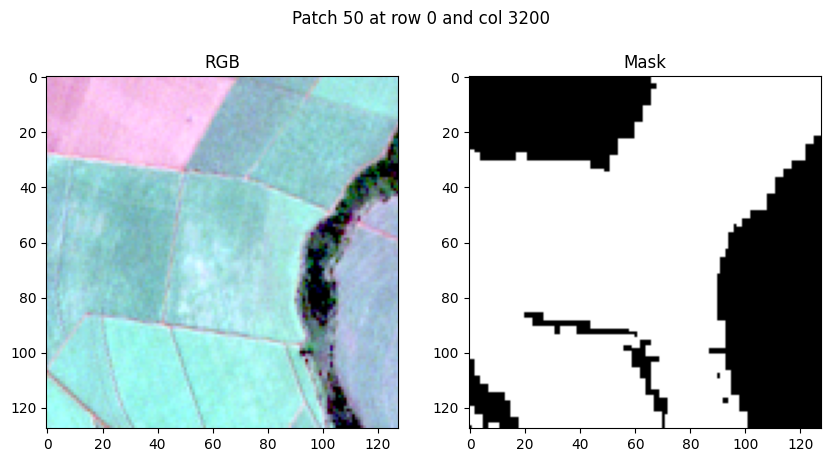

In [13]:
# Patch visualization for sanity check

patch_folder = base_path / "data" / "processed"
patch_index = pd.read_csv(patch_folder / "patch_index.csv")

idx = 50 # set this to the index of the patch you want to visualize

row = patch_index.iloc[idx]

x_patch = np.load(row["x_patch_path"])
y_patch = np.load(row["y_patch_path"])

fig, ax = plt.subplots(1, 2, figsize=(10,5))

plt.suptitle(f"Patch {row['patch_id']} at row {row['row_start']} and col {row['col_start']}")

rgb = x_patch[::1, ::1, [2, 1, 0]].copy()
#rgb = rgb[:, :, [2, 1, 0]] # If the bands are in BGR order, you can use this line instead to convert to RGB
rgb = stretch_rgb(rgb)

ax[0].imshow(rgb)
ax[0].set_title("RGB")

ax[1].imshow(y_patch, cmap="gray")
ax[1].set_title("Mask")

file_path = base_path / "figures" / "patch_image_with_mask.png"
plt.savefig(file_path, dpi=300, bbox_inches='tight')
print(f"\nVisualization saved as '{file_path}'")

plt.show()